# 1 · Counting Photons: What is Quantum Light?

**Lecture · Monday July 27, 11:30–12:30 · Tim Thomay**

### Learning objectives

After this lecture you can:

1. explain why photon-**number statistics** distinguish light sources that have *identical* average intensity,
2. write down and *recognize* the photon number distribution $P(n)$ for **coherent**, **thermal**, and **Fock** states, at any brightness,
3. compute and interpret the **Mandel $Q$ parameter** as a witness of non-classical light,
4. estimate **shot noise** in real measurements — from grainy night photos to why LIGO runs 200 kW of laser power and still had to squeeze the vacuum.

*References: Fox, "Quantum Optics" Ch. 5 [Fox2006]; Gerry & Knight Ch. 3 [GerryKnight2005]; original papers in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb, factorial
import qutip

# Course plot style: readable in the back row of the lecture hall.
plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)  # reproducible "experiments"
print("qutip", qutip.__version__)

qutip 5.3.0


## 1.0 · A short history of a reluctant idea (1900–1926)

The photon was forced on physics over the objections of nearly everyone involved — including its inventors:

| year | who | what |
|---|---|---|
| 1900 | <img src="../figures/planck.jpg" height="52" alt="Max Planck"/> **Planck** | quantizes the *exchange* of energy between light and matter, $E = h\nu$ — "an act of desperation" to fit the blackbody spectrum. He does not believe light itself is grainy. |
| 1905 | <img src="../figures/einstein.jpg" height="52" alt="Albert Einstein at the patent office"/> **Einstein** | takes the quanta seriously: light *consists* of independent energy quanta [Einstein1905]. Explains the photoelectric effect; this — not relativity — is his Nobel citation (1921). |
| 1909 | **G.I. Taylor** | photographs a diffraction pattern with light so feeble ("a candle burning at a distance slightly exceeding a mile") that quanta pass one at a time — the interference pattern survives [Taylor1909]. We repeat his experiment on a quantum processor on Wednesday. |
| 1909 | **Einstein again** | derives the energy fluctuations of blackbody radiation: a *sum of two terms*, one wave-like, one particle-like. Photon statistics is born in that formula — both terms reappear today in $(\Delta n)^2$. |
| 1916 | <img src="../figures/millikan.jpg" height="52" alt="Robert Millikan"/> **Millikan** | spends a decade trying to *disprove* the light quantum, confirms the photoelectric equation precisely [Millikan1916] — and still calls the theory "wholly untenable". |
| 1923 | <img src="../figures/compton.jpg" height="52" alt="Arthur Compton"/> **Compton** | X-ray quanta carry momentum $h\nu/c$ [Compton1923]. Resistance collapses. |
| 1926 | **G.N. Lewis** | coins the word *photon* [Lewis1926] (in a paper whose theory was wrong; the name outlived it). |

*Portraits (Planck 1918, Einstein at the Bern patent office ~1905, Millikan, Compton 1927): public domain / no known restrictions — [figures/FIGURES_CREDITS.md](../figures/FIGURES_CREDITS.md). No freely licensed photo of Taylor or Lewis exists.*

Then for thirty years almost nobody asked the next question: *how do photons arrive?* One by one? In clumps? At random? That question — **photon statistics** — created modern quantum optics (Tuesday's story), and it starts here.

## 1.1 · Three light sources walk into a bar…

Take three sources, all attenuated to the **same average power** — say $\bar n = 4$ photons per detection window:

* a **laser** → coherent light,
* a **filtered lamp** / starlight → thermal (*chaotic*) light,
* an ideal **single-photon gun** fired 4 times per window → Fock states.

A classical power meter *cannot tell them apart*. But light arrives in discrete photons, and a photon-counting detector sees three completely different streams of clicks.

**The photon number distribution $P(n)$ — the probability of finding $n$ photons in a measurement window — is the fingerprint of a light source.** Today we learn to read the fingerprint; the rest of the course is about measuring it (Tue) and engineering it (Wed).

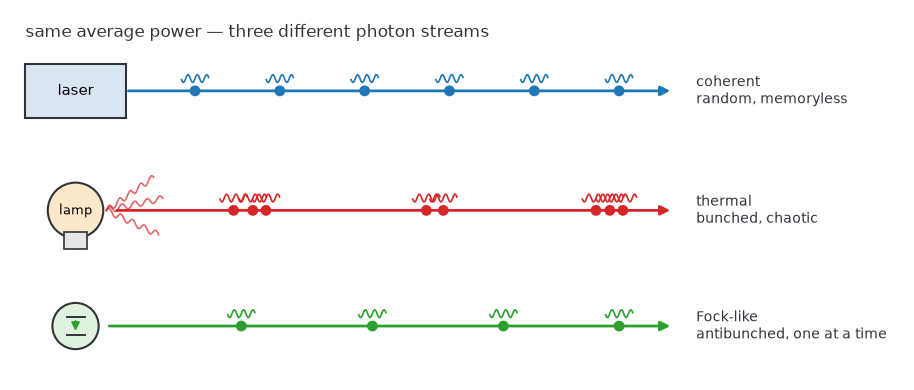

In [2]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.three_sources()

## 1.2 · One field mode = one harmonic oscillator

Maxwell's equations in a box separate the field into independent modes; each mode (one frequency $\omega$, one direction, one polarization) is mathematically a harmonic oscillator. Canonical quantization gives, per mode,

$$\hat H = \hbar\omega\left(\hat a^\dagger \hat a + \tfrac12\right),\qquad
[\hat a, \hat a^\dagger] = 1,\qquad \hat n = \hat a^\dagger \hat a ,$$

and the electric field of the mode is, up to the mode function,

$$\hat E \;\propto\; \hat X \cos\omega t + \hat P \sin\omega t,\qquad
\hat X = \tfrac{\hat a + \hat a^\dagger}{\sqrt2},\quad \hat P = \tfrac{\hat a - \hat a^\dagger}{i\sqrt2}.$$

The **quadratures** $\hat X, \hat P$ are the "position and momentum" of light: $\Delta X\,\Delta P \ge \tfrac12$. Even the vacuum has $\Delta X = \Delta P = 1/\sqrt2$ — **zero-point fluctuations**. Hold that thought: vacuum noise will turn out to be a *physical actor* (it limits LIGO — section 1.7 — and it seeds photon-pair generation on Wednesday).

**Fock (number) states** $|n\rangle$ are the eigenstates of $\hat n$ — exactly defined photon number:

$$\hat n |n\rangle = n|n\rangle, \qquad \hat a|n\rangle = \sqrt{n}\,|n-1\rangle, \qquad \hat a^\dagger|n\rangle = \sqrt{n+1}\,|n+1\rangle.$$

They are the natural basis for photon counting — and, with one honorable exception, no light source hands them to us ready-made. The exception is nature's most elementary emitter: a **single excited atom must emit exactly one photon** — a Fock-state $|1\rangle$ wavepacket, radiated into $4\pi$ (the hard part is *catching* it, not making it — Tuesday's story). Everything brighter than one atom emits states merely *built from* Fock states, and single-mode $|n\ge 2\rangle$ occurs nowhere in nature: that takes engineering (Wednesday). A caution from history, though: "no source emits phase-stable light" was equally obvious — until 1960. What common sources hand us is:

| state | definition | $P(n)$ | who emits it |
|---|---|---|---|
| **Fock** $\lvert n_0\rangle$ | $\hat n$ eigenstate | $\delta_{n,n_0}$ | a single excited emitter — one photon, once; $n\ge 2$ needs engineering (→ Wed) |
| **coherent** $\lvert\alpha\rangle$ | $\hat a\lvert\alpha\rangle = \alpha\lvert\alpha\rangle$ | $e^{-\bar n}\,\dfrac{\bar n^{\,n}}{n!}$ — **Poisson**, $\bar n = \lvert\alpha\rvert^2$ | ideal laser |
| **thermal** $\hat\rho_{\rm th}$ | max. entropy at fixed $\bar n$ | $\dfrac{\bar n^{\,n}}{(1+\bar n)^{n+1}}$ — **Bose–Einstein** | lamp, star, LED, ASE |

About the **coherent state**, the hero of the classical world: it is the *displaced vacuum*, $|\alpha\rangle = \hat D(\alpha)|0\rangle$ — the same minimal-uncertainty blob, pushed out to amplitude $|\alpha|$ in phase space. Its Poissonian statistics are those of **independent random events**: laser photons carry no memory of one another. (The laser: 1960, Maiman. That laser light is *statistically* different from lamp light — not just brighter — was only proven by photon counting in 1965/66, by Arecchi and others [Arecchi1965].)

> **A question I like to ask: *what makes a laser a laser?*** The usual answers dissolve on contact:
> * *"It's monochromatic."* — There is a **white-light laser** in my lab.
> * *"It's collimated."* — So is a lamp behind a pinhole; collimation is geometry, not physics.
> * *"It's stimulated emission."* — Inside the box, sure. But standing outside with only the beam: how would you *know*? What measurement shows it?
> * *"It has a threshold."* — Thresholdless lasers exist ($\beta \to 1$ microcavities).
>
> The answer that survives is the one Arecchi measured: **its photon statistics**. Poissonian counting — independent arrivals, no bunching, no memory — is the operational definition of laser light, and it is measurable from outside the box. Keep the question in mind all week: by tomorrow you can answer it with data.

The **thermal state** is the opposite character: maximum-entropy *mixed* state — many independent emitters with random phases. A star is thermal, and (Wednesday's spoiler) so is one arm of a photon-pair source when you ignore the other.

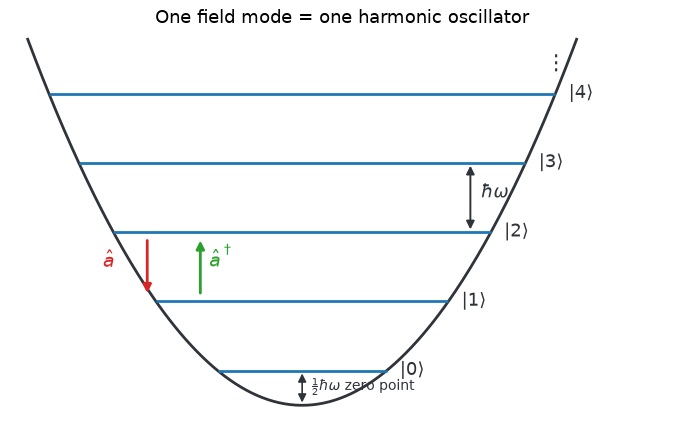

In [3]:
sketches.qho_ladder()

## 1.3 · The fingerprints: $P(n)$ at equal brightness

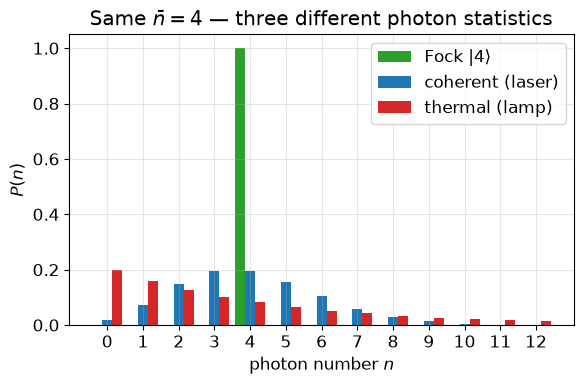

In [4]:
# Build the three states in QuTiP and read off P(n).
# QuTiP represents states in a truncated Fock space of dimension N:
# make N comfortably larger than any photon number we care about.
N = 100         # Fock-space cutoff; thermal states have long tails, and a
                # too-small cutoff silently biases variances - be generous
nbar = 4.0      # mean photon number, identical for all three sources

psi_fock = qutip.fock(N, int(nbar))          # |4>
psi_coh = qutip.coherent(N, np.sqrt(nbar))   # |alpha|^2 = nbar -> alpha = 2
rho_thermal = qutip.thermal_dm(N, nbar)      # mixed state, needs a density matrix

def photon_number_distribution(state) -> np.ndarray:
    """P(n) = diagonal of the density matrix in the Fock basis.

    Parameters
    ----------
    state : qutip.Qobj
        A ket or a density matrix of a single field mode.

    Returns
    -------
    np.ndarray
        P(n) for n = 0 .. N-1 (dimensionless probabilities, sum ~ 1).
    """
    rho = qutip.ket2dm(state) if state.isket else state
    return np.real(rho.diag())

fig, ax = plt.subplots()
n_axis = np.arange(13)
width = 0.28
for i, (label, state, color) in enumerate([
        ("Fock $|4\\rangle$", psi_fock, "tab:green"),
        ("coherent (laser)", psi_coh, "tab:blue"),
        ("thermal (lamp)", rho_thermal, "tab:red")]):
    P = photon_number_distribution(state)[:len(n_axis)]
    ax.bar(n_axis + (i - 1) * width, P, width, label=label, color=color)
ax.set_xlabel("photon number $n$")
ax.set_ylabel("$P(n)$")
ax.set_title(r"Same $\bar{n} = 4$ — three different photon statistics")
ax.set_xticks(n_axis)
ax.legend()
plt.tight_layout()
plt.show()

Read the fingerprints:

* **Fock**: a single spike. Zero uncertainty in photon number — maximal "quantumness" in $n$.
* **Coherent**: Poisson, peaked *near* $\bar n$ with width $\sqrt{\bar n}$ — independent random arrivals, like raindrops on a roof.
* **Thermal**: monotonic geometric decay — **$n=0$ is always the most likely outcome**, at any brightness (!), with a long tail: huge fluctuations. Photons arrive in *bunches*.

### …and across brightness

The same three families at $\bar n = 0.2$, $4$, and $25$ — because your intuition should work at *every* power level:

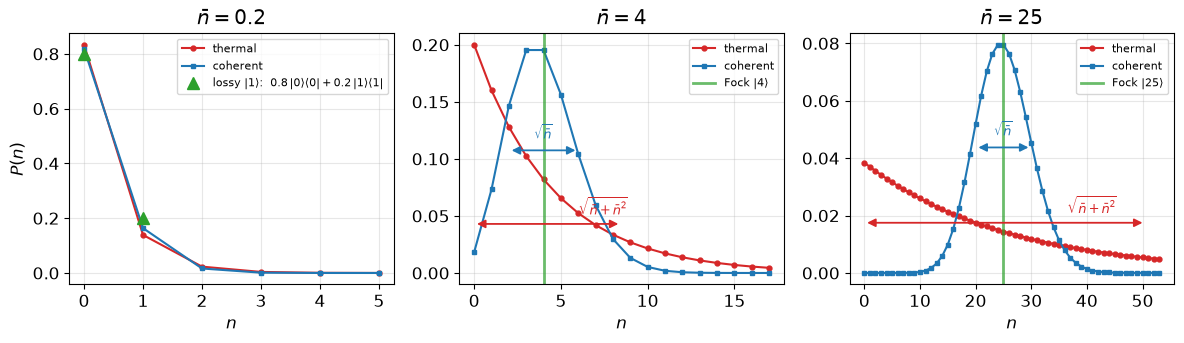

In [5]:
# The same fingerprints from the few-photon to the semi-classical regime.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, nb_ in zip(axes, [0.2, 4.0, 25.0]):
    nmax = int(nb_ + 5 * np.sqrt(nb_) + 4)
    n = np.arange(nmax)
    P_poisson = np.exp(-nb_) * nb_**n / factorial(n)
    P_thermal = nb_**n / (1 + nb_)**(n + 1)
    ax.plot(n, P_thermal, "o-", ms=3.5, color="tab:red", label="thermal")
    ax.plot(n, P_poisson, "s-", ms=3.5, color="tab:blue", label="coherent")
    if nb_ == int(nb_):
        ax.axvline(nb_, color="tab:green", lw=2, alpha=0.7,
                   label=f"Fock $|{nb_:g}\\rangle$")
        # sigma arrows: shot noise vs super-Poissonian thermal width
        s_c = np.sqrt(nb_)                  # coherent: sqrt(nbar)
        s_t = np.sqrt(nb_ + nb_**2)         # thermal: sqrt(nbar + nbar^2)
        y = P_poisson.max()
        ax.annotate("", xy=(nb_ - s_c, 0.55 * y), xytext=(nb_ + s_c, 0.55 * y),
                    arrowprops=dict(arrowstyle="<|-|>", color="tab:blue",
                                    lw=1.3))
        ax.text(nb_, 0.60 * y, r"$\sqrt{\bar{n}}$", color="tab:blue",
                ha="center", fontsize=9)
        ax.annotate("", xy=(max(nb_ - s_t, 0), 0.22 * y),
                    xytext=(nb_ + s_t, 0.22 * y),
                    arrowprops=dict(arrowstyle="<|-|>", color="tab:red",
                                    lw=1.3))
        ax.text(nb_ + 0.45 * s_t, 0.26 * y, r"$\sqrt{\bar{n}+\bar{n}^2}$",
                color="tab:red", fontsize=9)
    else:
        # There IS no Fock state with nbar = 0.2: photon numbers are
        # integers. The faint-light stand-in is a LOSSY single photon.
        ax.plot([0, 1], [0.8, 0.2], "^", ms=9, color="tab:green",
                label=r"lossy $|1\rangle$:  $0.8\,|0\rangle\langle 0| + 0.2\,|1\rangle\langle 1|$")
    ax.set_title(f"$\\bar{{n}} = {nb_:g}$")
    ax.set_xlabel("$n$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("$P(n)$")
plt.tight_layout()
plt.show()

Three regimes worth internalizing:

* **$\bar n \ll 1$** (single-photon regime, QKD, single emitters): coherent and thermal look *almost identical* — both are dominated by $P(0) \approx 1$, $P(1) \approx \bar n$. And note: there is **no Fock state at $\bar n = 0.2$** — photon numbers are integers; the faint-light stand-in is a *lossy* single photon, vacuum-diluted $|1\rangle$ (the state of check question 4). Statistics alone can barely distinguish anything here; you need *correlations* (tomorrow!).
* **$\bar n \sim$ a few**: the sweet spot where the fingerprints are most visible — this is where we simulate.
* **$\bar n \gg 1$** (classical regime): Poisson → narrow Gaussian, relative width $1/\sqrt{\bar n} \to 0$ (the classical "steady beam"); thermal *stays* ragged — the $\sigma$ arrows quantify it: $\sqrt{\bar n}$ (shot noise) vs $\sqrt{\bar n + \bar n^2}$ (**super-Poissonian**: wider than shot noise at every brightness, approaching $\bar n$ itself). Its relative fluctuations never die. A thermal field of macroscopic brightness still flickers by 100%.

## 1.4 · The same three states in phase space

$P(n)$ throws away all phase information. The full single-mode picture lives in phase space $(X, P)$, and the object that draws it is the **Wigner function** $W(x, p)$ — built to do exactly what a classical phase-space density does: integrate it over $p$ and you get the *true, measured* probability distribution of the $X$ quadrature; integrate over $x$ and you get that of $P$. Its **marginals are honest probabilities**, and homodyne tomography reconstructs $W$ from them in the lab — this is a measurable object, not a theorist's toy.

The catch: nothing forces $W$ *itself* to stay positive, and that is the entire diagnostic. Classical light — any classical light — is a statistical ensemble of fields, each with some amplitude and phase: a genuine probability cloud in phase space, non-negative everywhere by construction. If a state's $W$ has negative patches, **no such ensemble exists**: the negativity marks exactly where "a random classical field" stops being a possible description. *Negative Wigner values are the unforgeable signature of non-classicality.*

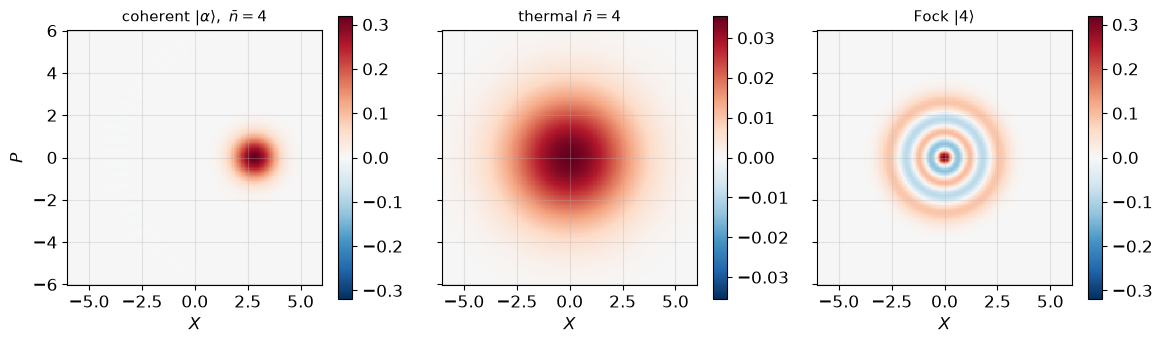

most negative Wigner value of |4>: -0.1292  <- impossible classically


In [6]:
# Wigner functions: coherent & thermal look classical; Fock states do not.
xvec = np.linspace(-6, 6, 201)
states_w = [(r"coherent $|\alpha\rangle,\ \bar{n}=4$", qutip.coherent(N, 2.0)),
            (r"thermal $\bar{n}=4$", qutip.thermal_dm(N, 4.0)),
            (r"Fock $|4\rangle$", qutip.fock(N, 4))]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, (label, st) in zip(axes, states_w):
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    im = ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("$X$")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, shrink=0.85)
axes[0].set_ylabel("$P$")
plt.tight_layout()
plt.show()

W_fock = qutip.wigner(qutip.fock(N, 4), xvec, xvec)
print(f"most negative Wigner value of |4>: {W_fock.min():.4f}  <- impossible classically")

* **Coherent**: a minimum-uncertainty Gaussian blob displaced from the origin — a classical "amplitude + phase" arrow, plus unavoidable vacuum fuzz. (Phase and photon number are conjugate: sharp phase ⇒ fuzzy $n$.)
* **Thermal**: a fat Gaussian *at the origin* — random amplitude, completely random phase. Positive everywhere: classical noise.
* **Fock**: concentric rings diving **below zero**. Sharp photon number, *no phase at all* — and beware the tempting reading: **this is *not* an uncertainty principle**, however much it resembles one. The ring is not "phase noise smeared in a circle": rotating a number state in phase space only changes an unobservable global phase ($|n\rangle \to e^{-in\theta}|n\rangle$), so its $W$ *must* be rotationally symmetric — a **symmetry** statement, not a noise statement. And no Heisenberg relation could make the rings anyway: uncertainty *broadens* distributions, it never drives them below zero. (Strictly there is not even a phase operator conjugate to $\hat n$ — the naive $\Delta n\,\Delta\varphi \ge \frac{1}{2}$ already fails for the vacuum, where $\Delta n = 0$ yet the phase spread cannot exceed $2\pi$.) The negative rings are **interference fringes in phase space**. No classical field ensemble can produce this.

Keep the triptych in mind: *coherent and thermal states are classical lookalikes; Fock states are the genuinely quantum objects.*


### Aside · Is the circle *exact*? Even that is a testable claim

Everything above assumed standard quantum mechanics — and notice how little freedom it leaves. Once the photon-number statistics are pinned to exactly $P(n) = \delta_{nk}$, Hilbert space has **no remaining choices**: the state *must* be $|k\rangle$, its total quadrature variance *must* be $\langle X^2\rangle + \langle P^2\rangle = 2k+1$, and its Wigner rings *must* be perfectly round. Fock statistics pin the second moments completely; there is no quantum state with the number distribution of $|k\rangle$ and any other variance.

That rigidity makes the circle **falsifiable**. In a discrete model we are currently developing with UB colleagues (an extension of [Powers2025], with proposed experiments), the oscillator lives on a register of $n$ bits rather than an infinite-dimensional Hilbert space. The state $|k\rangle$ then keeps its *exact* photon-number statistics — yet its quadrature variance drops to $(2k+1) - 2k^2/n$, and the Wigner rings turn slightly **elliptical**. No quantum state can imitate that combination. A Fock state that is not circular would mean nature has *run out of information capacity* per mode.

So homodyne tomography of the rings you just plotted is not merely state characterization — measuring the roundness of a Fock state is a **test of quantum mechanics itself**. In standard QM, and only there, the circle is exact. (The beamsplitter side of the same research program returns on Wednesday.)

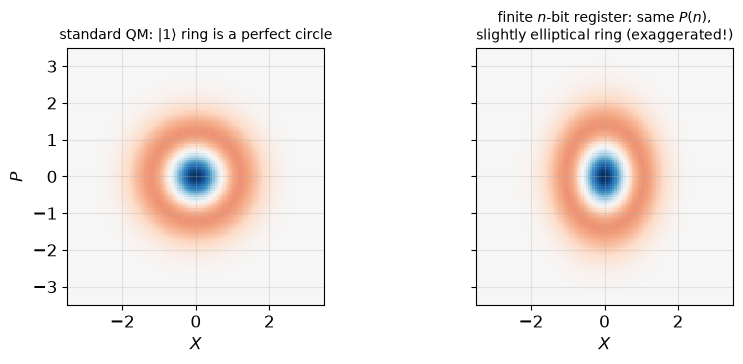

In [7]:
# Cartoon: what a finite-register Fock state would look like.
# The predicted ellipticity is O(k^2/n) - tiny. Exaggerated ~15% here so
# your eyes can see what the experiment would look for.
st1 = qutip.fock(N, 1)
eps = 1.15                                   # exaggeration factor
W_qm = qutip.wigner(st1, xvec, xvec)
W_reg = qutip.wigner(st1, xvec * eps, xvec / eps)   # squeezed coordinates

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, (label, W) in zip(axes, [
        (r"standard QM: $|1\rangle$ ring is a perfect circle", W_qm),
        ("finite $n$-bit register: same $P(n)$,\nslightly elliptical ring "
         "(exaggerated!)", W_reg)]):
    vmax = np.abs(W).max()
    ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("$X$")
    ax.set_aspect("equal")
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
axes[0].set_ylabel("$P$")
plt.tight_layout()
plt.show()

## 1.5 · Quantifying the width: variance and the Mandel $Q$ parameter

$$(\Delta n)^2_{\rm Fock} = 0, \qquad (\Delta n)^2_{\rm coh} = \bar n, \qquad (\Delta n)^2_{\rm th} = \bar n + \bar n^2.$$

Look at the thermal result: this is **Einstein's 1909 fluctuation formula** — a *particle* term $\bar n$ (shot noise — defined properly in the next section) plus a *wave* term $\bar n^2$ (classical intensity beats). Wave–particle duality, hiding in a variance.

Mandel's $Q$ [Mandel1979] measures the deviation from pure shot noise:

$$\boxed{\;Q = \frac{(\Delta n)^2 - \bar n}{\bar n}\;}\qquad
\begin{cases}
Q = 0 & \text{Poissonian (coherent)}\\
Q > 0 & \text{super-Poissonian (thermal: } Q = \bar n)\\
-1 \le Q < 0 & \text{sub-Poissonian (Fock: } Q = -1)
\end{cases}$$

**Why we care:** any *classical* intensity ensemble gives $Q \ge 0$ — classical fields can only *add* noise on top of shot noise (two-line Cauchy–Schwarz proof tomorrow). Measuring $Q < 0$ is **proof of non-classical light** — predicted for resonance fluorescence by Mandel [Mandel1979], first observed by Short & Mandel in 1983 [ShortMandel1983]. (Its cousin *antibunching* came first, in 1977, from the fluorescence of a sodium atomic beam with on average a single atom in view [Kimble1977] — tomorrow's story.)

In [8]:
def mandel_Q(state) -> float:
    """Mandel Q parameter of a single-mode state.

    Q = (variance(n) - <n>) / <n>. Q=0 Poissonian, Q<0 sub-Poissonian
    (non-classical), Q>0 super-Poissonian.
    """
    N_dim = state.shape[0]
    n_op = qutip.num(N_dim)
    mean = qutip.expect(n_op, state)
    var = qutip.expect(n_op**2, state) - mean**2
    return (var - mean) / mean

for label, state in [("Fock |4>  ", psi_fock),
                     ("coherent  ", psi_coh),
                     ("thermal   ", rho_thermal)]:
    print(f"{label}: Q = {mandel_Q(state):+.3f}")

Fock |4>  : Q = -1.000
coherent  : Q = +0.000
thermal   : Q = +4.000


## 1.6 · Shot noise in the real world

**What "shot noise" actually is.** Light of perfectly constant classical intensity still arrives as discrete, statistically independent photons. Independent random arrivals at a fixed average rate are the *definition* of a Poisson process — and for a Poisson distribution the variance equals the mean: $(\Delta N)^2 = \bar N$. The resulting $\sqrt{\bar N}$ jitter in every count is **shot noise**: the granularity (the "shot") of the beam itself, not a defect of the detector, and not removable by a better amplifier. (The name is Schottky's, 1918, for the identical effect with electrons in vacuum tubes.) It is the noise floor of every classical-light measurement — beatable only by changing the *statistics* of the light: $Q < 0$, or the squeezing of section 1.7.

So: Poissonian counting means $\Delta N = \sqrt{\bar N}$, so every intensity measurement with $\bar N$ detected photons has

$$\text{signal-to-noise ratio} \;\le\; \frac{\bar N}{\sqrt{\bar N}} = \sqrt{\bar N}
\qquad\Longleftrightarrow\qquad
\text{relative noise} = \frac{1}{\sqrt{\bar N}} .$$

That innocent square root runs half of experimental physics. Worked numbers:

| measurement | photons collected $\bar N$ | shot-noise floor $1/\sqrt{\bar N}$ |
|---|---|---|
| phone photo pixel, night mode | $\sim 10^2$ | **10%** — that's the grain you see |
| phone photo pixel, sunlight | $\sim 10^4$ | 1% — smooth |
| 1 mW laser pointer, 1 s integration | $2.7\times10^{15}$ | $2\times10^{-8}$ |
| fluorescence of *one* molecule, 1 ms bin | $\sim 10^2$ | 10% — single-molecule biophysics fights this daily |
| LIGO circulating beam, 10 ms | $\sim 10^{22}$ | $10^{-11}$ — and *still not good enough* (next section) |

Photon counting is one of the very few games where the noise floor is set by *how much light you collect*, not by your amplifier — and improving it means either **more photons** ($\sqrt{N}$: painful) or **better statistics than Poisson** ($Q<0$ or squeezing: quantum optics' sales pitch).

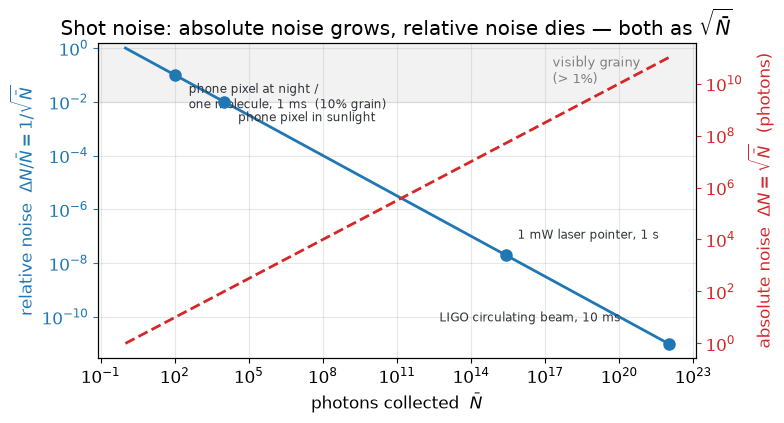

In [9]:
# One law, 22 orders of magnitude: shot noise vs collected photons.
Nbar = np.logspace(0, 22, 200)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.loglog(Nbar, 1 / np.sqrt(Nbar), color="tab:blue", lw=2)
ax.set_ylabel(r"relative noise  $\Delta N/\bar{N} = 1/\sqrt{\bar{N}}$",
              color="tab:blue")
ax.tick_params(axis="y", colors="tab:blue")
ax.set_xlabel(r"photons collected  $\bar{N}$")

ax2 = ax.twinx()
ax2.loglog(Nbar, np.sqrt(Nbar), color="tab:red", lw=2, ls="--")
ax2.set_ylabel(r"absolute noise  $\Delta N = \sqrt{\bar{N}}$  (photons)",
               color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")
ax2.grid(False)

# the worked examples from the table
examples = [
    (1e2, "phone pixel at night /\none molecule, 1 ms  (10% grain)", (10, -24)),
    (1e4, "phone pixel in sunlight", (10, -14)),
    (2.7e15, "1 mW laser pointer, 1 s", (8, 12)),
    (1e22, "LIGO circulating beam, 10 ms", (-165, 16)),
]
for N_ex, label, off in examples:
    ax.plot(N_ex, 1 / np.sqrt(N_ex), "o", ms=8, color="tab:blue", zorder=5)
    ax.annotate(label, (N_ex, 1 / np.sqrt(N_ex)), textcoords="offset points",
                xytext=off, fontsize=8.5, color="#30343a")

ax.axhspan(0.01, 1.5, color="gray", alpha=0.10)
ax.text(2e17, 0.05, "visibly grainy\n(> 1%)", fontsize=9, color="gray")
ax.set_ylim(3e-12, 1.5)
ax.set_title("Shot noise: absolute noise grows, relative noise dies "
             r"— both as $\sqrt{\bar{N}}$")
plt.tight_layout()
plt.show()

# The 'huge variance' reading: LIGO's beam fluctuates by ~1e11 photons
# per measurement in ABSOLUTE terms - yet that is a relative error of
# 1e-11, the quietest measurement in this plot. Which axis matters is
# set by what you measure: fringe positions care about the relative one.

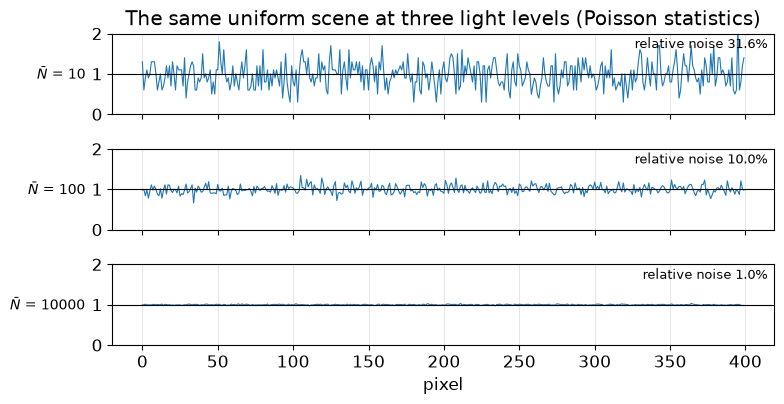

In [10]:
# Shot noise you have personally seen: photon counts across an 'image' row.
# A uniform gray scene photographed at three light levels.
pixels = 400
fig, axes = plt.subplots(3, 1, figsize=(8, 4.2), sharex=True)
for ax, Nbar in zip(axes, [10, 100, 10_000]):
    counts = rng.poisson(Nbar, pixels)
    ax.plot(counts / Nbar, lw=0.8)
    ax.axhline(1, color="k", lw=0.8)
    ax.set_ylim(0, 2)
    ax.set_ylabel(f"$\\bar N$ = {Nbar}", rotation=0, ha="right", va="center",
                  fontsize=10)
    ax.text(0.99, 0.82, f"relative noise {1/np.sqrt(Nbar):.1%}",
            transform=ax.transAxes, ha="right", fontsize=9)
axes[-1].set_xlabel("pixel")
axes[0].set_title("The same uniform scene at three light levels (Poisson statistics)")
plt.tight_layout()
plt.show()

## 1.7 · Case study: LIGO, the strong laser, and the vacuum that enters through the dark port

A gravitational-wave interferometer measures a *phase difference* between two 4 km arms. At the shot-noise limit, the phase uncertainty per measurement is

$$\Delta\varphi_{\rm shot} \simeq \frac{1}{\sqrt{\bar N}},$$

and LIGO needs $\Delta\varphi \sim 10^{-11}$ — displacement sensitivity of $10^{-18}$ m, a thousandth of a proton radius — to hear black holes collide [Abbott2016]. Hence design decision #1: **as strong a laser as the optics survive** — hundreds of kW circulating in the arms, because every factor 100 in power buys only a factor 10 in phase noise.

But brute force saturated. The next insight is pure quantum optics [Caves1981]: analyze *where the noise actually comes from*, and it is **not** the laser. The interferometer's beamsplitter has **two** input ports — the laser enters one, and the other, the "dark port"… is empty. Empty means **vacuum state**, and vacuum fluctuations ($\Delta X = \Delta P = 1/\sqrt2$, section 1.2) enter there, beat against the laser field, and produce exactly the shot noise at the readout.

Caves' 1981 proposal: *replace* the vacuum at the dark port with **squeezed vacuum** — a state with $\Delta X < 1/\sqrt2$ in the measured quadrature (at the price of $\Delta P > 1/\sqrt2$, as Heisenberg collects his fee). Nothing about the laser changes; you improve the interferometer by upgrading *the state of nothing*.

It took ~30 years of squeezer engineering [Schnabel2017]; since 2019 LIGO and Virgo run with squeezed light injected into the dark port, gaining up to ~3 dB of sensitivity — a **40–50% increase in the expected detection rate** [Tse2019]. GEO600 holds the kilometer-scale record: 6.0 dB of quantum-noise reduction [Lough2021]. This is photon statistics as an astronomy instrument.

**Open-quantum-systems dictionary** (for this school's shared language): the interferometer is a system coupled to the *continuum of vacuum modes* — a zero-temperature bath. Shot noise is bath-induced noise entering through a specific port, and squeezing is **bath engineering**: you do not touch the system, you prepare the *environment* in a nonclassical state. You will meet the same move as "squeezed reservoirs" in the open-systems lectures of this school.

<p align="center"><img src="../figures/ligo_hanford.jpg" width="620" alt="LIGO Hanford aerial view"/></p>

*LIGO Hanford: 4 km of vacuum pipe per arm, hunting a phase shift of $10^{-11}$ rad. Photo: LIGO Laboratory, public domain.*

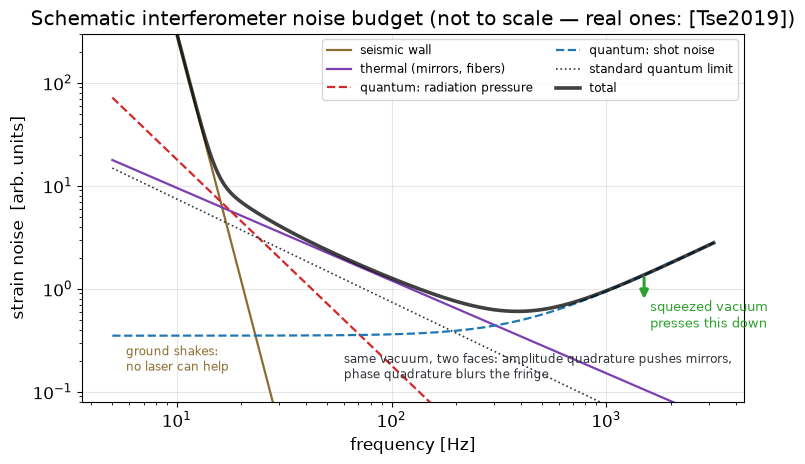

In [11]:
sketches.ligo_noise_budget()

How to read a noise budget (every gravitational-wave talk shows one): you live on the **bottom envelope**. Below ~20 Hz the ground itself is the wall — no light source fixes seismics. In the middle, thermal motion of mirror coatings and suspension fibers. And the two dashed curves are the stars of this lecture: **both are the same dark-port vacuum**, seen through its two quadratures. The *amplitude* quadrature physically kicks the 40 kg mirrors around (radiation pressure, dominating at low frequency); the *phase* quadrature blurs the fringe readout (shot noise, dominating at high frequency). Their crossing traces the **standard quantum limit**.

That duality is also squeezing's fine print: squeeze the phase quadrature and Heisenberg *pumps up* the amplitude one — the 2019 deployment [Tse2019] improved the shot-noise shoulder at the price of slightly worse radiation pressure at low frequency. The 2023 upgrade closed even that loophole with **frequency-dependent squeezing**: a 300 m filter cavity rotates the squeeze ellipse with frequency, so each band gets the quadrature it needs. Vacuum engineering, frequency by frequency.

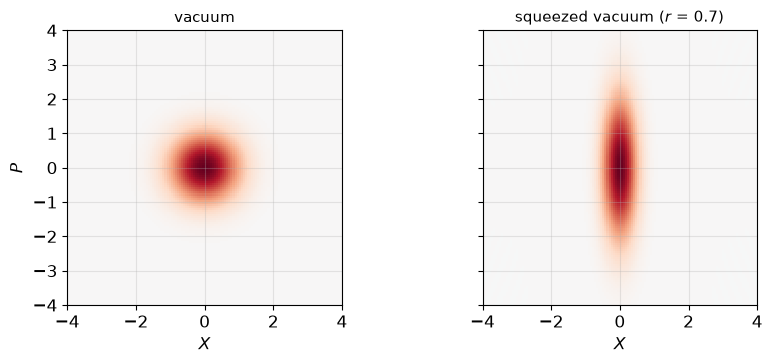

vacuum          : dX = 0.707, dP = 0.707, dX*dP = 0.500
squeezed vacuum : dX = 0.351, dP = 1.424, dX*dP = 0.500

P(n) of squeezed vacuum: [0.797 0.    0.146 0.    0.04  0.    0.012 0.   ]


In [12]:
# The state of nothing, upgraded: vacuum vs squeezed vacuum.
r = 0.7                                    # squeezing parameter (~6 dB)
vac = qutip.fock(N, 0)
sq_vac = qutip.squeeze(N, r) * vac         # squeezed vacuum state

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, (label, st) in zip(axes, [("vacuum", vac),
                                  (f"squeezed vacuum ($r$ = {r})", sq_vac)]):
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("$X$")
    ax.set_aspect("equal")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
axes[0].set_ylabel("$P$")
plt.tight_layout()
plt.show()

for label, st in [("vacuum          ", vac), ("squeezed vacuum ", sq_vac)]:
    dX = np.sqrt(qutip.variance(qutip.position(N), st))
    dP = np.sqrt(qutip.variance(qutip.momentum(N), st))
    print(f"{label}: dX = {dX:.3f}, dP = {dP:.3f}, dX*dP = {dX*dP:.3f}")

# Bonus fingerprint: squeezed vacuum contains only EVEN photon numbers -
# photons are born in pairs. Remember this on Wednesday (SPDC!).
P_sq = photon_number_distribution(sq_vac)[:8]
print("\nP(n) of squeezed vacuum:", np.array2string(P_sq, precision=3))

Two things to take away from the printout:

* the squeezed vacuum indeed has $\Delta X < \Delta X_{\rm vac}$ with $\Delta X\,\Delta P$ still $\ge \tfrac12$ — noise is *redistributed*, not destroyed;
* its $P(n)$ contains **only even photon numbers**: squeezed light is made of photon *pairs*. The two-mode version of this state is exactly what a down-conversion crystal emits — Wednesday we will herald single photons out of it.

*Three questions should be itching by now — **is a Fock state secretly squeezed? shouldn't LIGO run on Fock states, since they have no photon-number noise at all? and why has nobody ever noticed thermal statistics in daylight?** All three are this afternoon's opening demos, where you can compute the answers yourself (notebook [`02_HandsOn_SimulatingPhotonStatistics`](02_HandsOn_SimulatingPhotonStatistics.ipynb)).*

## 1.8 · What the detector actually sees: click streams

$P(n)$ is an abstraction — a photon counter produces a **stream of time tags**. A 2 ms simulated recording of our three sources (same average rate!); tomorrow you analyze exactly such data quantitatively.

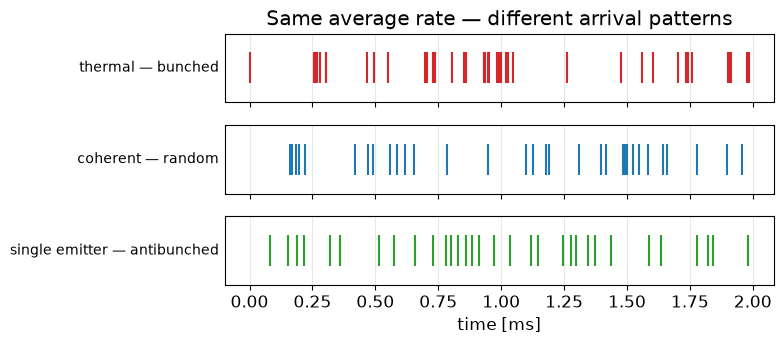

In [13]:
# Simulate 'click' arrival times (simplified versions of data/make_timetags.py).
rate = 20e3        # mean detected rate [clicks/s]
T_show = 2e-3      # displayed time window [s]

# coherent light: memoryless Poisson process
t_coherent = np.sort(rng.uniform(0, T_show, rng.poisson(rate * T_show)))

# thermal light: intensity fluctuates on the coherence time scale (bunching)
tau_c = 50e-6                                  # coherence time [s]
n_slots = int(T_show / tau_c)
intensity = rng.exponential(1.0, n_slots)      # single-mode thermal: I ~ exp
counts = rng.poisson(rate * tau_c * intensity)
t_thermal = np.sort(np.concatenate(
    [(k + rng.uniform(size=c)) * tau_c for k, c in enumerate(counts)]))

# single emitter: a dead time after every photon (antibunching)
gaps = rng.exponential(1 / rate, int(3 * rate * T_show)) + 20e-6  # 20 us dead time
t_emitter = np.cumsum(gaps)
t_emitter = t_emitter[t_emitter < T_show]

fig, axes = plt.subplots(3, 1, figsize=(8, 3.6), sharex=True)
for ax, (label, t, color) in zip(axes, [
        ("thermal — bunched", t_thermal, "tab:red"),
        ("coherent — random", t_coherent, "tab:blue"),
        ("single emitter — antibunched", t_emitter, "tab:green")]):
    ax.eventplot(t * 1e3, colors=color, linelengths=0.8)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
axes[-1].set_xlabel("time [ms]")
axes[0].set_title("Same average rate — different arrival patterns")
plt.tight_layout()
plt.show()

Thermal clicks come in **clusters** (bunching), coherent clicks are **patternless**, and the single emitter keeps a minimum distance between clicks (**antibunching**) — it must be re-excited before it can emit again.

## 1.9 · Where do these states live in the lab?

| source | state | $Q$ | typical $\bar n$ per mode |
|---|---|---|---|
| laser above threshold | coherent | $0$ | anything you like |
| laser *at* threshold | partly thermal | $>0$ | Arecchi's 1965 counting experiment [Arecchi1965] |
| lamp, LED, star, ASE | thermal | $\bar n$ | $\ll 1$ (optical), $\gg 1$ (radio) |
| attenuated laser pulse | still coherent! | $0$ | $\sim 0.1$ (used in QKD) |
| squeezed vacuum (LIGO dark port) | pairs only, even $n$ | $>0$ (!) | $\ll 1$ |
| single atom / molecule / quantum dot / NV center | approx. $\lvert 1\rangle$ | $\to -1$ | $\le 1$ |
| heralded SPDC (→ Lecture 6) | $\lvert 1\rangle$, $\lvert 2\rangle$, … | $\to -1$ | $\le 1$ |

Two traps worth remembering:

* **Attenuating a laser never makes single photons.** Loss thins Poisson into sparser Poisson — $Q$ stays 0. A "0.1 photons per pulse" laser still has two-photon events; quantum key distribution had to invent decoy states because of this.
* **Thermal light doesn't mean "hot".** It means *chaotic*: many independent emitters with random phases. And strictly, every lab "thermal" source only *approximates* thermal statistics; arguably the only **exactly** thermal emitter nature provides is a black hole — the horizon guarantees a perfectly thermal spectrum [Hawking1975]. We meet the mechanism on Wednesday.

## 1.10 · Check your understanding

1. Where exactly in Einstein's fluctuation formula $(\Delta n)^2 = \bar n + \bar n^2$ do "wave" and "particle" live? Which term survives for coherent light, and why?
2. You attenuate the Fock state $\lvert 4\rangle$ with 50% loss. Is the output still a Fock state? Still sub-Poissonian? *(You simulate exactly this after lunch.)*
3. Why is $Q = -1$ the most negative value possible?
4. A source emits $\lvert 1 \rangle$ with probability $p$, vacuum otherwise. Compute $Q$. Is a lossy single-photon source still non-classical?
5. Note the table above: squeezed vacuum has $Q > 0$ — super-Poissonian! — yet it is deeply non-classical (Wigner negativity in the two-mode version, LIGO improvement). Moral: $Q < 0$ is *sufficient* for non-classicality, not *necessary*. Which witness catches squeezed vacuum?
6. LIGO doubles its circulating power. By how much does the shot-noise-limited strain sensitivity improve? How many dB of squeezing achieve the same?

**This afternoon (14:00):** we build all of today's states in code, *live* — sampling detector clicks, plotting Wigner functions, watching loss eat the quantumness ([`02_HandsOn_SimulatingPhotonStatistics`](02_HandsOn_SimulatingPhotonStatistics.ipynb)). No laptop needed — bring predictions. **Tonight, the week's only evening task (~20 min):** the setup notebook [`00_Setup_GitHub_Codespaces`](00_Setup_GitHub_Codespaces.ipynb) — fork, Codespace, one test cell — so that from tomorrow you can work hands-on.